#House Clustering Using K-Means Clustering Techniques

**Author**- Nikhil B Nair & Khushi Pragya


**Objective**- To group similar houses into meaningful clusters using the K-Means clustering algorithm based on their features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("House Price Prediction Dataset.csv")

In [4]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


**Shape of Dataset**

In [5]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])


Number of Rows : 2000
Number of Columns : 10


**Checking for missing values**

In [6]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


**Check datatypes**

In [7]:
df.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


Location, Condition and Garage are categorical. We encode them.

**Encoding**

In [23]:
encoder = LabelEncoder()

df["Location"] = encoder.fit_transform(df["Location"])
df["Condition"] = encoder.fit_transform(df["Condition"])
df["Garage"] = encoder.fit_transform(df["Garage"])
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Cluster
0,1360,5,4,3,1970,0,0,0,149919,3
1,4272,5,4,3,1958,0,0,0,424998,3
2,3592,2,2,3,1938,0,2,0,266746,3
3,966,4,2,2,1902,2,1,1,244020,0
4,4926,1,4,2,1975,0,1,1,636056,2


In [9]:
df = df.drop("Id", axis=1)

**Feature scaling**

In [10]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,-1.101471,1.401791,1.305568,1.244151,0.238155,-1.274332,-1.316267,-0.962695,-1.403091
1,1.147485,1.401791,1.305568,1.244151,-0.095942,-1.274332,-1.316267,-0.962695,-0.407725
2,0.622317,-0.704581,-0.498326,1.244151,-0.652770,-1.274332,0.460072,-0.962695,-0.980356
3,-1.405759,0.699667,-0.498326,0.008035,-1.655061,0.486403,-0.428098,1.038750,-1.062589
4,1.652574,-1.406705,1.305568,0.008035,0.377363,-1.274332,-0.428098,1.038750,0.355982


**Elbow method**

In [11]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

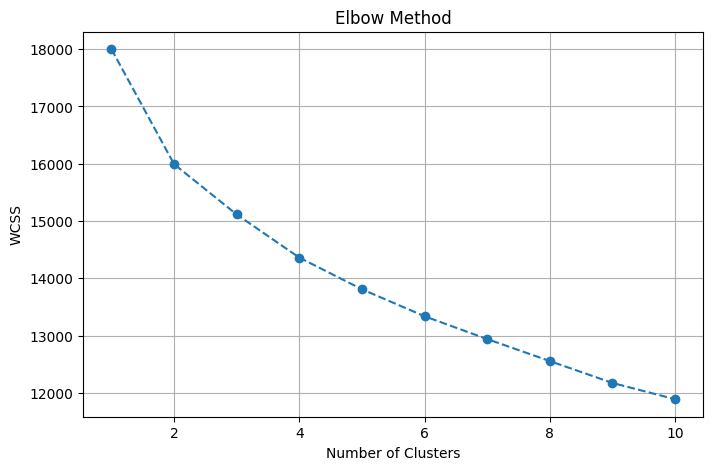

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    linestyle='--'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

K=4

**Train the K Means model**

In [24]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

df["Cluster"] = clusters

In [25]:
df["Cluster"].value_counts()

,count
Cluster,
3,543
2,504
1,495
0,458


Tells us the number of houses in each cluster

**Cluster** **centers**

In [27]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns.drop("Cluster")
)

**PCA with cluster centers**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


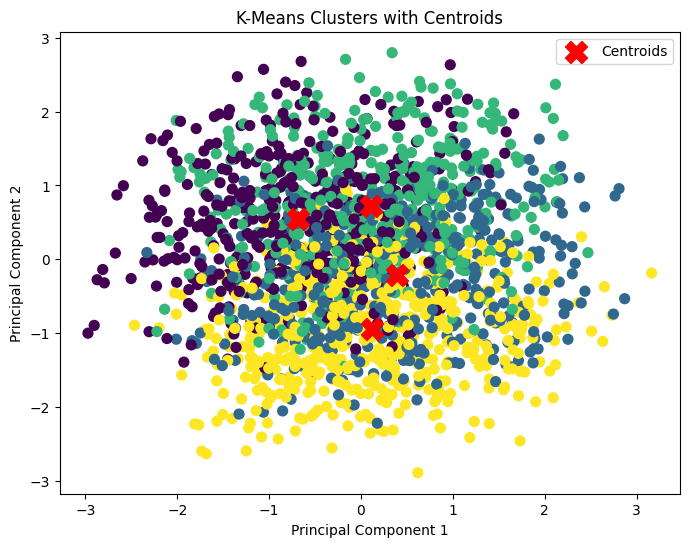

In [28]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(scaled_df)

centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis',
    s=50
)

plt.scatter(
    centers_pca[:,0],
    centers_pca[:,1],
    c='red',
    s=250,
    marker='X',
    label='Centroids'
)

plt.legend()
plt.title("K-Means Clusters with Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

Plotting the cluster centroids along with the data points.

In [29]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
Cluster,,,,,,,,,
0,2849.168122,2.882096,2.286026,1.700873,1962.253275,1.473799,1.556769,1.0,312542.663755
1,2797.383838,3.111111,2.498990,2.004040,1960.773737,2.517172,1.470707,0.0,541018.836364
2,2720.162698,2.996032,2.803571,2.251984,1959.878968,1.468254,1.501984,1.0,743820.402778
3,2784.222836,3.014733,2.593002,1.990792,1962.832413,0.430939,1.410681,0.0,533184.830571


Tells us the cluster wise mean

**Boxplot for comparing price distribution among clusters**

<Figure size 800x600 with 0 Axes>

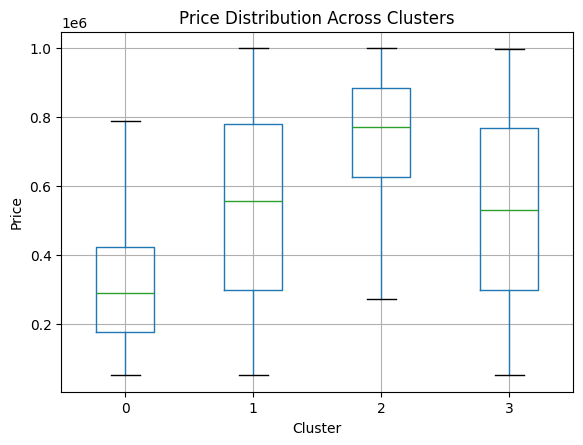

In [30]:
plt.figure(figsize=(8,6))

df.boxplot(column="Price", by="Cluster")

plt.title("Price Distribution Across Clusters")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Price")

plt.show()

## Conclusion

K-Means clustering was successfully applied to segment houses into four clusters based on their features. The Elbow Method was used to determine the optimal number of clusters, and the results were visualized using PCA and box plots. The analysis identified distinct groups of houses with different pricing patterns and property characteristics, demonstrating the effectiveness of K-Means for exploratory data analysis.